In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

## Implementation From Scratch

Taking :

**$$y = 0.05 + \sum_{i = 1}^d 0.01 x_i + \epsilon \textrm{ where }
\epsilon \sim \mathcal{N}(0, 0.01^2).$$**

In this synthetic dataset, our label is given 
by an underlying linear function of our inputs,
corrupted by Gaussian noise 
with zero mean and standard deviation 0.01.
For illustrative purposes, 
we can make the effects of overfitting pronounced,
by increasing the dimensionality of our problem to $d = 200$


In [2]:
class Data(d2l.DataModule):
    def __init__(self, num_train, num_val, num_inputs, batch_size):
        self.save_hyperparameters()
        n = num_train + num_val
        self.X = torch.randn(n, num_inputs)
        noise = torch.randn(n, 1) * 0.01
        w, b = torch.ones((num_inputs, 1)) * 0.01, 0.05
        self.y = torch.matmul(self.X, w) + b + noise

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.y], train, i)

Penalty :

In [3]:
def l2_penalty(w):
    return (w ** 2).sum() / 2

Defining the Model with Weight Decay :

In [4]:
class WeightDecayScratch(d2l.LinearRegressionScratch):
    def __init__(self, num_inputs, lambd, lr, sigma=0.01):
        super().__init__(num_inputs, lr, sigma)
        self.save_hyperparameters()

    def loss(self, y_hat, y):
        return (super().loss(y_hat, y) +
                self.lambd * l2_penalty(self.w))

This code trains with 20 examples and evaluate with 100 of them

We can choose the $\lambda$ constant by `train_scratch`

In [5]:
data = Data(num_train=20, num_val=100, num_inputs=200, batch_size=5)
trainer = d2l.Trainer(max_epochs=10)

def train_scratch(lambd):
    model = WeightDecayScratch(num_inputs=200, lambd=lambd, lr=0.01)
    model.board.yscale='log'
    trainer.fit(model, data)
    print('L2 norm of w:', float(l2_penalty(model.w)))

- $\lambda = 0$ (Disabling weight decay)

L2 norm of w: 0.009765838272869587


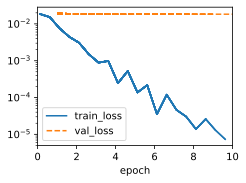

In [6]:
train_scratch(0)

- $\lambda = 3$ :

L2 norm of w: 0.0017807476688176394


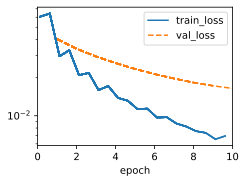

In [7]:
train_scratch(3)

We notice that the training error increases while validation error decreases 

# Concise Implementation

The frameworks already integrated the weight decay because it is ubiquitous in NN

In [8]:
class WeightDecay(d2l.LinearRegression):
    def __init__(self, wd, lr):
        super().__init__(lr)
        self.save_hyperparameters()
        # self.wd = wd # LOL already done with prev method

    def configure_optimizers(self):
        # Implementing custom decay where it affects only weights not bias
        # Old Version w/o decay:
        # return torch.optim.SGD(self.parameters(), self.lr)
        return torch.optim.SGD([
            {'params': self.net.weight, 'weight_decay': self.wd},
            {'params': self.net.bias}], lr=self.lr)

L2 norm of w: 0.015716267749667168


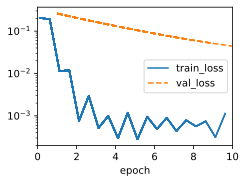

In [9]:
model = WeightDecay(wd=3, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

L2 norm of w: 0.0032861928921192884


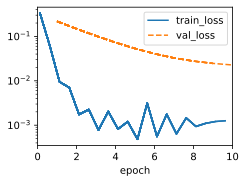

In [10]:
model = WeightDecay(wd=5, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

## Exercises

1. Experiment with the value of $\lambda$ in the estimation problem in this section. Plot training and validation accuracy as a function of $\lambda$. What do you observe?
1. Use a validation set to find the optimal value of $\lambda$. Is it really the optimal value? Does this matter?
1. What would the update equations look like if instead of $\|\mathbf{w}\|^2$ we used $\sum_i |w_i|$ as our penalty of choice ($\ell_1$ regularization)?
1. We know that $\|\mathbf{w}\|^2 = \mathbf{w}^\top \mathbf{w}$. Can you find a similar equation for matrices (see the Frobenius norm)?
1. Review the relationship between training error and generalization error. In addition to weight decay, increased training, and the use of a model of suitable complexity, what other ways might help us deal with overfitting?
1. In Bayesian statistics we use the product of prior and likelihood to arrive at a posterior via $P(w \mid x) \propto P(x \mid w) P(w)$. How can you identify $P(w)$ with regularization?


1.

L2 norm of w: 0.00020328345999587327


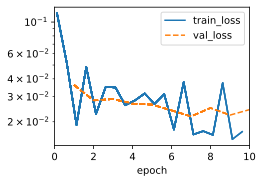

In [11]:
model = WeightDecay(wd=50, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

L2 norm of w: 0.0001949780562426895


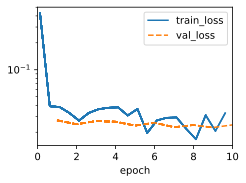

In [12]:
model = WeightDecay(wd=100, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

L2 norm of w: 0.000240984300035052


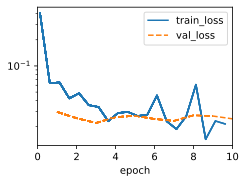

In [13]:
model = WeightDecay(wd=150, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

At some point too much of $\lambda$ makes the function diverge

L2 norm of w: 359121.09375


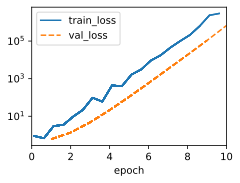

In [15]:
model = WeightDecay(wd=200, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

L2 norm of w: inf


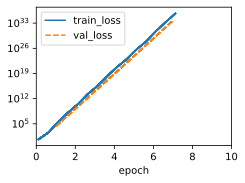

In [14]:
model = WeightDecay(wd=500, lr=0.01)
model.board.yscale='log'
trainer.fit(model, data)

print('L2 norm of w:', float(l2_penalty(model.get_w_b()[0])))

We can notice that evaluation loss can't get below training loss when it gets too close it diverges (Underfitting)

| $\lambda$ |  Training error | Validation error | Interpretation |
| ----------: | --------------: | ---------------: | -------------- |
|  Very small |             Low |    Possibly high | Overfitting    |
|    Moderate | Slightly higher |           Lowest | Good tradeoff  |
|  Very large |            High |             High | Underfitting   |


### 2.

Estimating by previous testing we have $\lambda \in [150, 200]$

In [ ]:
def train_model(lambd):
    model = WeightDecayScratch(
        num_inputs=200,
        lambd=lambd,
        lr=0.01
    )

    trainer = d2l.Trainer(max_epochs=10)

    model.board.yscale = "log"
    model.board.display = False

    trainer.fit(model, data)

    return model

In [42]:
def evaluate_loss(model, dataloader):
    losses = []

    with torch.no_grad():
        for X, y in dataloader:
            y_hat = model(X)
            y = y.reshape(y_hat.shape)

            losses.append(((y_hat - y) ** 2 / 2).mean())

    return float(torch.stack(losses).mean())

Best lambda: 185
Best validation loss: 0.011019201017916203


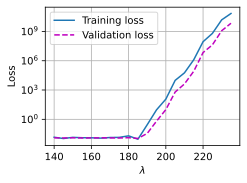

In [60]:
best_lambda = None
best_val_loss = float("inf")

lambdas = list(range(140, 240, 5))
train_losses = []
val_losses = []

for lambd in lambdas:
    model = train_model(lambd)

    train_loss = evaluate_loss(
        model,
        data.train_dataloader()
    )

    val_loss = evaluate_loss(
        model,
        data.val_dataloader()
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lambda = lambd

d2l.plot(
    lambdas,
    [train_losses, val_losses],
    xlabel=r"$\lambda$",
    ylabel="Loss",
    yscale="log",
    legend=["Training loss", "Validation loss"]
)

print("Best lambda:", best_lambda)
print("Best validation loss:", best_val_loss)

To be more precise

Best lambda: 183
Best validation loss: 0.011361480690538883


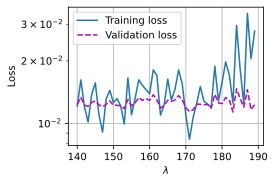

In [59]:
best_lambda = None
best_val_loss = float("inf")

lambdas = list(range(140, 190, 1))
train_losses = []
val_losses = []

for lambd in lambdas:
    model = train_model(lambd)

    train_loss = evaluate_loss(
        model,
        data.train_dataloader()
    )

    val_loss = evaluate_loss(
        model,
        data.val_dataloader()
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lambda = lambd

d2l.plot(
    lambdas,
    [train_losses, val_losses],
    xlabel=r"$\lambda$",
    ylabel="Loss",
    yscale="log",
    legend=["Training loss", "Validation loss"]
)

print("Best lambda:", best_lambda)
print("Best validation loss:", best_val_loss)

A moderate $\lambda$ can sacrifice a little training performance while substantially improving validation performance.

#### Is it really optimal? Does it matter?

We train one model for every candidate \(\lambda\), measure its validation loss, and select

$$
\hat{\lambda}
=
\arg\min_{\lambda\in\Lambda}
L_{\mathrm{val}}(\lambda).
$$

In our experiment, the best value varied between roughly

$$
\lambda=145\text{ and }190
$$

across repeated runs.

Therefore, the selected value is not necessarily the true optimal $\lambda$. It is only the best value:

* among the values tested;
* for this particular validation set;
* for this random initialization and minibatch order;
* with the chosen optimizer and number of epochs.

Randomness can change the winner when nearby values have similar validation losses. The exact optimum usually does not matter if the validation curve is nearly flat around its minimum. In this case, the useful conclusion is that a value in the approximate range $140–190$ works well, rather than that one exact value is uniquely optimal.

A separate test set should then be used to estimate the final model’s generalization error, because the validation set has already influenced our choice.


#### 3. Using $\ell_1$

Replace the penalty with

$$
\lambda\|\mathbf w\|_1
=
\lambda\sum_{j=1}^d |w_j|.
$$

The regularized minibatch objective becomes

$$
L_{\mathcal B}(\mathbf w,b)
=
\frac{1}{2|\mathcal B|}
\sum_{i\in\mathcal B}
\left(
\mathbf w^\top\mathbf x^{(i)}+b-y^{(i)}
\right)^2
+
\lambda\sum_{j=1}^d|w_j|.
$$

For $w_j \neq 0$,

$$
\frac{\partial |w_j|}{\partial w_j}
=
\operatorname{sign}(w_j)
=
\begin{cases}
1, & w_j>0,\\
-1, & w_j<0.
\end{cases}
$$

Therefore, the update for each weight is :

$$
\boxed{
\mathbf w
\leftarrow
\mathbf w
-
\frac{\eta}{|\mathcal B|}
\sum_{i\in\mathcal B}
\mathbf x^{(i)}
\left(
\mathbf w^\top\mathbf x^{(i)}+b-y^{(i)}
\right)
-
\eta\lambda\operatorname{sign}(\mathbf w)
}
$$

where `sign` is applied elementwise.

At $w_j=0$, $|w_j|$ is not differentiable. Instead it has the subgradient

$$
\partial |w_j|
=
[-1,1].
$$

A common implementation chooses \(0\) as the subgradient at zero.

Unlike \(\ell_2\) regularization, this update does not multiply every weight by a common decay factor. It subtracts the same magnitude \(\eta\lambda\) from every nonzero weight in the direction of zero:

$$
w_j>0
\implies
w_j\leftarrow w_j-\eta\lambda,
$$

$$
w_j<0
\implies
w_j\leftarrow w_j+\eta\lambda.
$$

This stronger behavior near zero encourages weights to become exactly zero, producing sparse models and effectively performing feature selection.

A more precise optimization method uses the soft-thresholding update. First perform the data-loss step:

$$
\mathbf u
=
\mathbf w-\eta\nabla_{\mathbf w}L_{\text{data}},
$$

then apply

$$
\boxed{
w_j
\leftarrow
\operatorname{sign}(u_j)
\max\left(|u_j|-\eta\lambda,0\right)
}
$$

This prevents a small positive weight from simply jumping past zero and becoming negative; instead, sufficiently small weights are set exactly to zero.


## 4. Frobenius Norm Equiv for Matrices

For a matrix $\mathbf W\in\mathbb R^{m\times n}$, the corresponding norm is the **Frobenius norm**:

$$
\|\mathbf W\|_F^2
=
\sum_{i=1}^m\sum_{j=1}^n W_{ij}^2.
$$

Where

$$
\boxed{
\|\mathbf W\|_F^2
=
\operatorname{tr}\left(\mathbf W^\top\mathbf W\right)
}
$$

because

$$
\begin{aligned}

\|\mathbf W\|_F^2
=
\sum_{j=1}^n(\mathbf W^\top\mathbf W)_{jj}
=
\sum_{j=1}^n\sum_{i=1}^m W_{ij}^2
=
\operatorname{tr}(\mathbf W^\top\mathbf W)

\end{aligned}
$$

Therefore, ordinary gradient descent produces the same decay term:

$$
\mathbf W
\leftarrow
(1-\eta\lambda)\mathbf W
-
\eta\nabla_{\mathbf W}L_{\text{data}}.
$$


### 5.
- Data augmentation : modified versions of training examples that preserve their labels, such as cropping, rotating, or flipping images.
- Early stopping : Measure validation loss during training and stop when it begins to increase.
- Dropout : Randomly deactivate some neurons during training. Encourages more robust representations
- Adding noise (for inputs/gradients/parameters...): makes exact memorization harder and can encourage smoother functions
- Cross-validation : Train and validate using several different data splits.
- Ensembles : Train several models and average their predictions.
- Transfer learning : Begin with a model trained on a larger related dataset, then fine-tune it on the smaller target dataset.

### 6.

Bayes Rule :  $P(w \mid x) \propto P(x \mid w) P(w)$.


# ADJUST LATER

## 6. How can \(P(\mathbf w)\) be identified with regularization?

Bayes’ rule gives

$$
P(\mathbf w\mid \mathcal D)
\propto
P(\mathcal D\mid\mathbf w)P(\mathbf w),
$$

where:

* \(P(\mathcal D\mid\mathbf w)\) is the likelihood;
* \(P(\mathbf w)\) is the prior over weights;
* \(P(\mathbf w\mid\mathcal D)\) is the posterior.

To find the most probable weights, we use maximum a posteriori estimation:

$$
\mathbf w_{\mathrm{MAP}}
=
\arg\max_{\mathbf w}
P(\mathbf w\mid\mathcal D).
$$

Using the posterior expression,

$$
\mathbf w_{\mathrm{MAP}}
=
\arg\max_{\mathbf w}
P(\mathcal D\mid\mathbf w)P(\mathbf w).
$$

Taking the negative logarithm changes maximization into minimization:

$$
\boxed{
\mathbf w_{\mathrm{MAP}}
=
\arg\min_{\mathbf w}
\left[
-\log P(\mathcal D\mid\mathbf w)
-
\log P(\mathbf w)
\right].
}
$$

This has exactly the form

$$
\boxed{
\text{data loss}+\text{regularization penalty}.
}
$$

Therefore, regularization can be interpreted as the negative logarithm of a prior:

$$
\boxed{
R(\mathbf w)=-\log P(\mathbf w)+\text{constant}.
}
$$

### Gaussian prior gives \(\ell_2\) regularization

Suppose

$$
\mathbf w\sim\mathcal N(\mathbf 0,\tau^2\mathbf I).
$$

Then

$$
P(\mathbf w)
\propto
\exp\left(
-\frac{1}{2\tau^2}\|\mathbf w\|_2^2
\right).
$$

Taking the negative logarithm:

$$
-\log P(\mathbf w)
=
\frac{1}{2\tau^2}\|\mathbf w\|_2^2
+\text{constant}.
$$

This is an \(\ell_2\) penalty:

$$
\frac{\lambda}{2}\|\mathbf w\|_2^2,
$$

where \(\lambda\) is related to the inverse prior variance:

$$
\lambda\propto\frac{1}{\tau^2}.
$$

Thus:

* small \(\tau^2\), a narrow prior, means strong confidence that weights should be near zero and therefore strong regularization;
* large \(\tau^2\), a broad prior, means weaker regularization.

### Laplace prior gives \(\ell_1\) regularization

If the weights independently follow a Laplace distribution,

$$
P(\mathbf w)
\propto
\exp\left(
-\frac{1}{\beta}\sum_j|w_j|
\right),
$$

then

$$
-\log P(\mathbf w)
=
\frac{1}{\beta}\sum_j|w_j|
+\text{constant}.
$$

This gives the \(\ell_1\) penalty

$$
\lambda\|\mathbf w\|_1.
$$

So the correspondence is:

| Prior          | Resulting regularization  |
| -------------- | ------------------------- |
| Gaussian prior | \(\ell_2\) regularization |
| Laplace prior  | \(\ell_1\) regularization |

From the Bayesian perspective, regularization expresses a prior belief about plausible model parameters. Weight decay corresponds to believing that weights are probably near zero before observing the training data. Not regularizing the bias can similarly be viewed as assigning it a very broad or approximately uniform prior.
